In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature


In [2]:
df = pd.read_csv("viirs_thermal_hotspots.csv")

In [3]:
# Basic info
print(df.shape)
print(df.columns)
df.info()
df.head()

(1590050, 16)
Index(['OBJECTID', 'latitude', 'longitude', 'bright_ti4', 'scan', 'track',
       'acq_date', 'acq_time', 'satellite', 'confidence', 'version',
       'bright_ti5', 'frp', 'daynight', 'esritimeutc', 'hours_old'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1590050 entries, 0 to 1590049
Data columns (total 16 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   OBJECTID     1590050 non-null  int64  
 1   latitude     1590050 non-null  float64
 2   longitude    1590050 non-null  float64
 3   bright_ti4   1590050 non-null  float64
 4   scan         1590050 non-null  float64
 5   track        1590050 non-null  float64
 6   acq_date     1590050 non-null  object 
 7   acq_time     1590050 non-null  object 
 8   satellite    1590050 non-null  object 
 9   confidence   1590050 non-null  object 
 10  version      1590050 non-null  object 
 11  bright_ti5   1590050 non-null  float64
 12  frp          1590

,OBJECTID,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,confidence,version,bright_ti5,frp,daynight,esritimeutc,hours_old
0,1,30.37129,27.22985,322.26,0.37,0.58,2025-09-06,2025-09-06 00:41:00,N,nominal,2.0NRT,290.25,1.64,N,2025-09-06 07:41:00,182
1,2,30.53483,26.07778,303.15,0.63,0.54,2025-09-06,2025-09-06 00:41:00,N,nominal,2.0NRT,291.03,1.81,N,2025-09-06 07:41:00,182
2,3,30.53332,26.08426,311.66,0.63,0.54,2025-09-06,2025-09-06 00:41:00,N,nominal,2.0NRT,291.96,1.81,N,2025-09-06 07:41:00,182
3,4,30.53181,26.09074,302.32,0.63,0.54,2025-09-06,2025-09-06 00:41:00,N,nominal,2.0NRT,291.70,1.10,N,2025-09-06 07:41:00,182
4,5,32.82307,12.96935,308.89,0.48,0.40,2025-09-06,2025-09-06 00:41:00,N,nominal,2.0NRT,295.42,1.50,N,2025-09-06 07:41:00,182


In [34]:
df.tail()

,OBJECTID,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,confidence,version,bright_ti5,frp,daynight,esritimeutc,hours_old,log_frp
1590045,1590046,41.40744,-7.52997,346.48,0.54,0.51,2025-09-13,2025-09-13 12:46:00,N21,nominal,2.0NRT,295.25,20.36,D,2025-09-13 19:46:00,2,1.308778
1590046,1590047,51.48399,6.72138,337.21,0.41,0.45,2025-09-13,2025-09-13 12:49:00,N21,nominal,2.0NRT,292.99,7.84,D,2025-09-13 19:49:00,2,0.894316
1590047,1590048,51.48301,6.70955,338.04,0.41,0.45,2025-09-13,2025-09-13 12:49:00,N21,nominal,2.0NRT,293.11,5.29,D,2025-09-13 19:49:00,2,0.723456
1590048,1590049,51.48253,6.70366,326.10,0.41,0.45,2025-09-13,2025-09-13 12:49:00,N21,nominal,2.0NRT,293.07,5.29,D,2025-09-13 19:49:00,2,0.723456
1590049,1590050,51.49366,6.73737,331.54,0.41,0.45,2025-09-13,2025-09-13 12:49:00,N21,nominal,2.0NRT,293.40,6.32,D,2025-09-13 19:49:00,2,0.800717


In [4]:
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
print(missing_percent.sort_values(ascending=False))

OBJECTID       0.0
latitude       0.0
longitude      0.0
bright_ti4     0.0
scan           0.0
track          0.0
acq_date       0.0
acq_time       0.0
satellite      0.0
confidence     0.0
version        0.0
bright_ti5     0.0
frp            0.0
daynight       0.0
esritimeutc    0.0
hours_old      0.0
dtype: float64


In [5]:
df[['bright_ti4', 'bright_ti5', 'frp', 'hours_old']].describe()

,bright_ti4,bright_ti5,frp,hours_old
count,1.590050e+06,1.590050e+06,1.590050e+06,1.590050e+06
mean,3.363871e+02,3.018346e+02,1.070623e+01,9.144194e+01
std,1.747162e+01,1.097456e+01,2.060450e+01,5.422331e+01
min,2.073800e+02,2.278000e+02,0.000000e+00,1.000000e+00
25%,3.314500e+02,2.940000e+02,3.070000e+00,4.700000e+01
50%,3.389200e+02,3.032700e+02,5.830000e+00,9.400000e+01
75%,3.465000e+02,3.094900e+02,1.081000e+01,1.450000e+02
max,3.670000e+02,3.868600e+02,2.032000e+03,1.820000e+02


In [13]:
df['log_frp'] = np.log10(df['frp'].clip(lower=1))


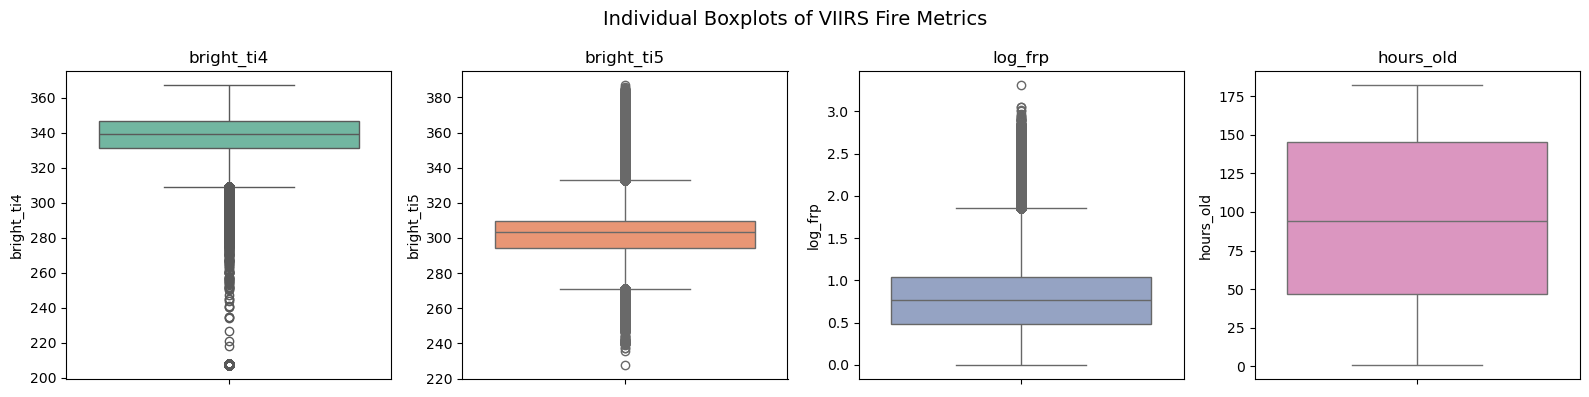

In [18]:
cols = ['bright_ti4', 'bright_ti5', 'log_frp', 'hours_old']
subset = df[cols]

# Get Set2 palette
palette = sns.color_palette("Set2", len(cols))

# Create subplots
fig, axes = plt.subplots(1, len(cols), figsize=(16, 4), sharey=False)

# Plot each boxplot with its own color
for i, col in enumerate(cols):
    sns.boxplot(y=subset[col].dropna(), ax=axes[i], color=palette[i])
    axes[i].set_title(f'{col}')

# Final touches
fig.suptitle("Individual Boxplots of VIIRS Fire Metrics", fontsize=14)
plt.tight_layout()
plt.show()



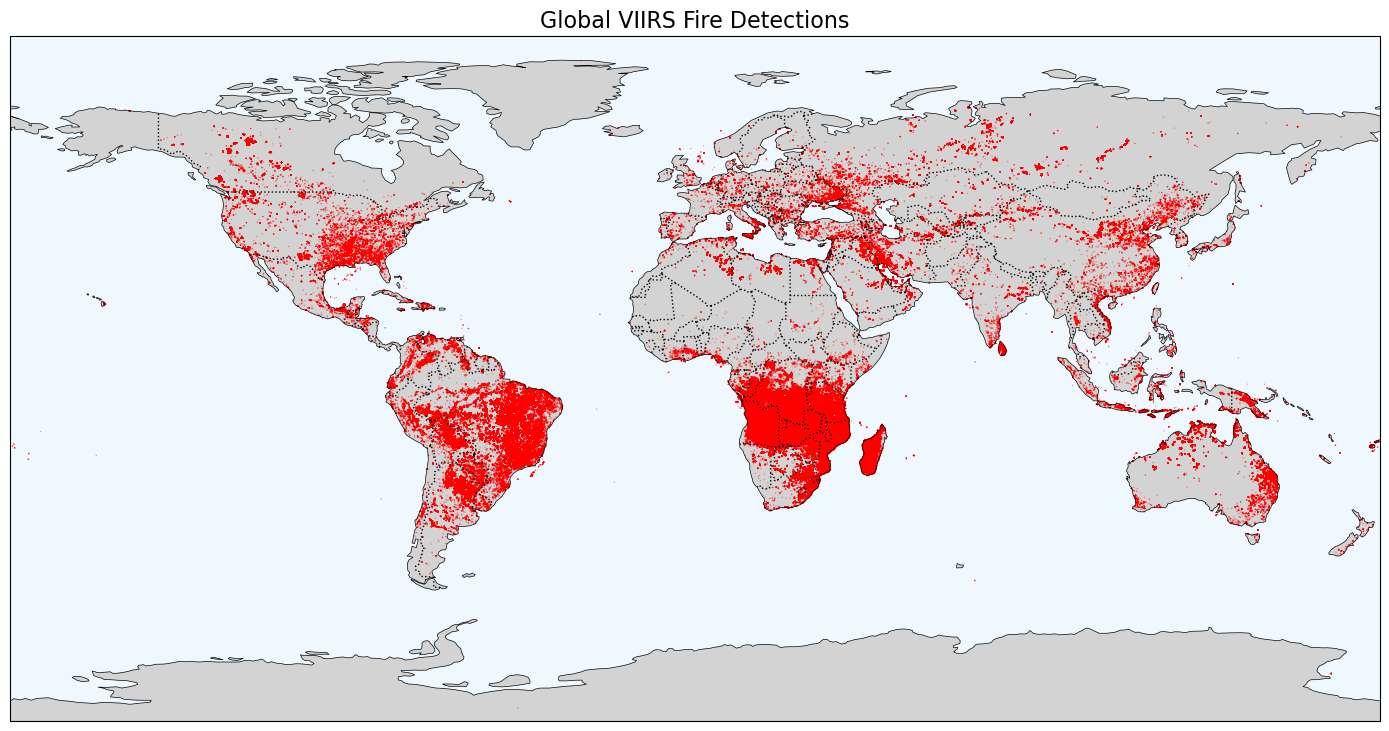

In [30]:
fig = plt.figure(figsize=(14, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='aliceblue')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linestyle=':')

# Plot fire detections scaled by FRP
scatter = ax.scatter(
    df['longitude'],
    df['latitude'],
    s=1,
    c='red',
    alpha=0.4,
    transform=ccrs.PlateCarree(),
    edgecolors='none'
)

# Labels and layout
ax.set_title("Global VIIRS Fire Detections", fontsize=16)
plt.tight_layout()
plt.show()

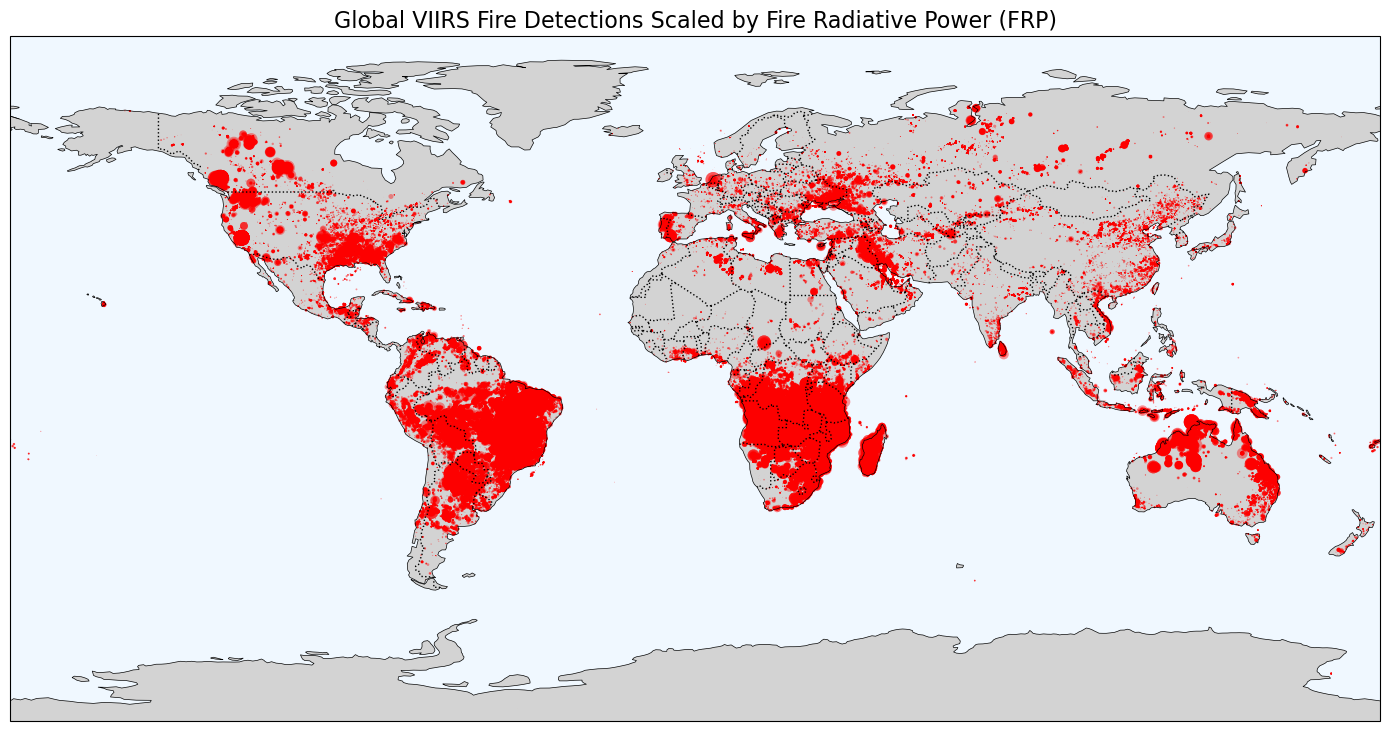

In [31]:
fig = plt.figure(figsize=(14, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='aliceblue')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linestyle=':')

# Plot fire detections scaled by FRP
scatter = ax.scatter(
    df['longitude'],
    df['latitude'],
    s=df['frp'].clip(upper=500) / 4,  # Scale size, clip extreme FRP
    c='red',
    alpha=0.4,
    transform=ccrs.PlateCarree(),
    edgecolors='none'
)

# Labels and layout
ax.set_title("Global VIIRS Fire Detections Scaled by Fire Radiative Power (FRP)", fontsize=16)
plt.tight_layout()
plt.show()


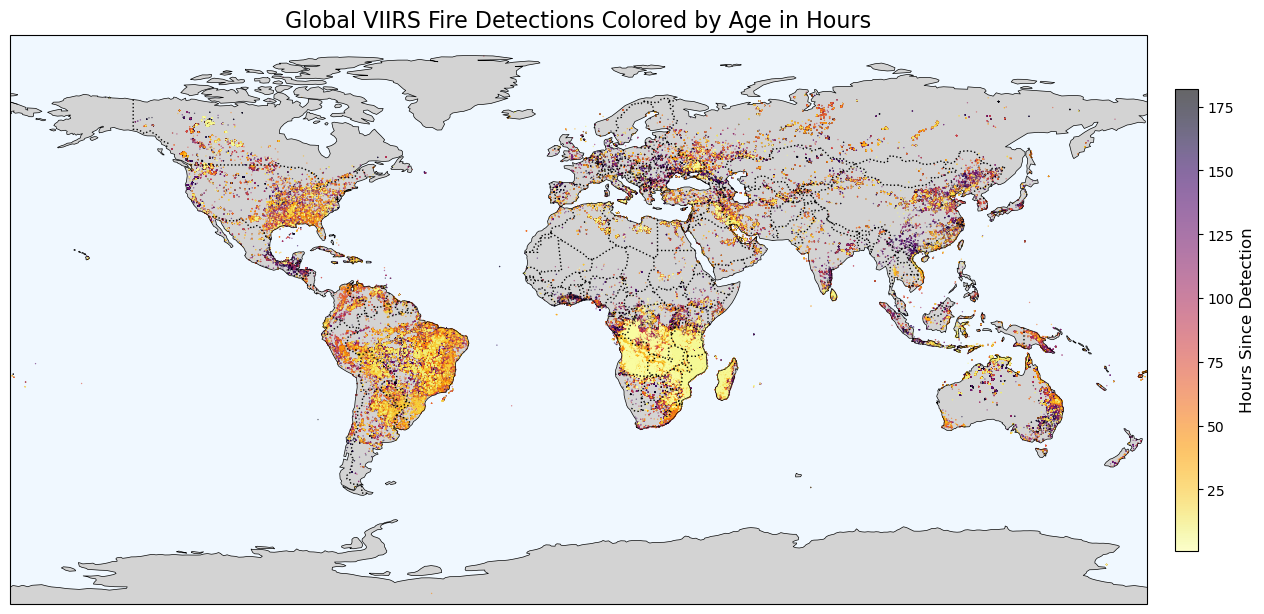

In [33]:
#  Setup figure and map projection
fig = plt.figure(figsize=(14, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='aliceblue')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linestyle=':')

# Plot fire detections with color gradient by hours_old
scatter = ax.scatter(
    df['longitude'],
    df['latitude'],
    s=1,  # Small uniform size
    c=df['hours_old'],
    cmap='inferno_r',
    alpha=0.6,
    transform=ccrs.PlateCarree(),
    edgecolors='none'
)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax, orientation='vertical', shrink=0.6, pad=0.02)
cbar.set_label('Hours Since Detection', fontsize=12)

# Final touches
ax.set_title("Global VIIRS Fire Detections Colored by Age in Hours", fontsize=16)
plt.tight_layout()
plt.show()

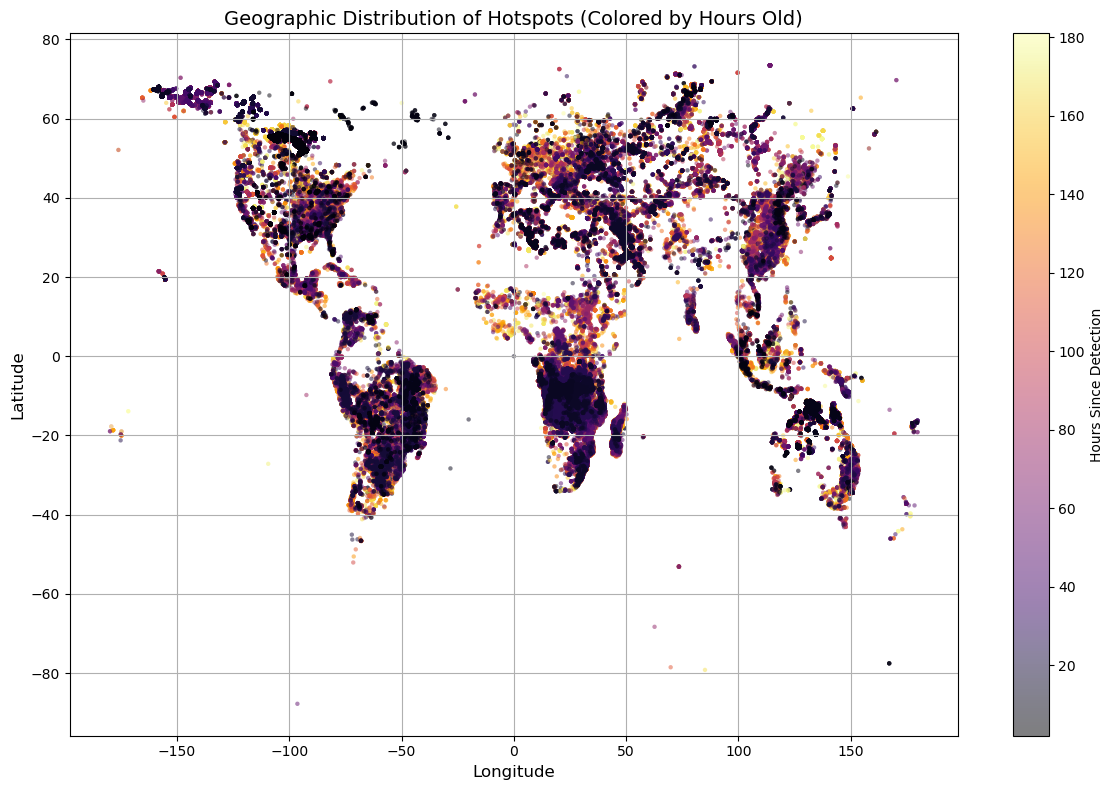

In [21]:
plt.figure(figsize=(12, 8))  # Keep the larger canvas

# Color by hours_old, using a perceptually uniform colormap
scatter = plt.scatter(
    df['longitude'],
    df['latitude'],
    c=df['hours_old'],
    cmap='inferno',
    alpha=0.5,
    s=10,
    edgecolors='none'
)

plt.title("Geographic Distribution of Hotspots (Colored by Hours Old)", fontsize=14)
plt.xlabel("Longitude", fontsize=12)
plt.ylabel("Latitude", fontsize=12)
plt.grid(True)
plt.colorbar(scatter, label='Hours Since Detection')  # Legend for color gradient
plt.tight_layout()
plt.show()
